In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

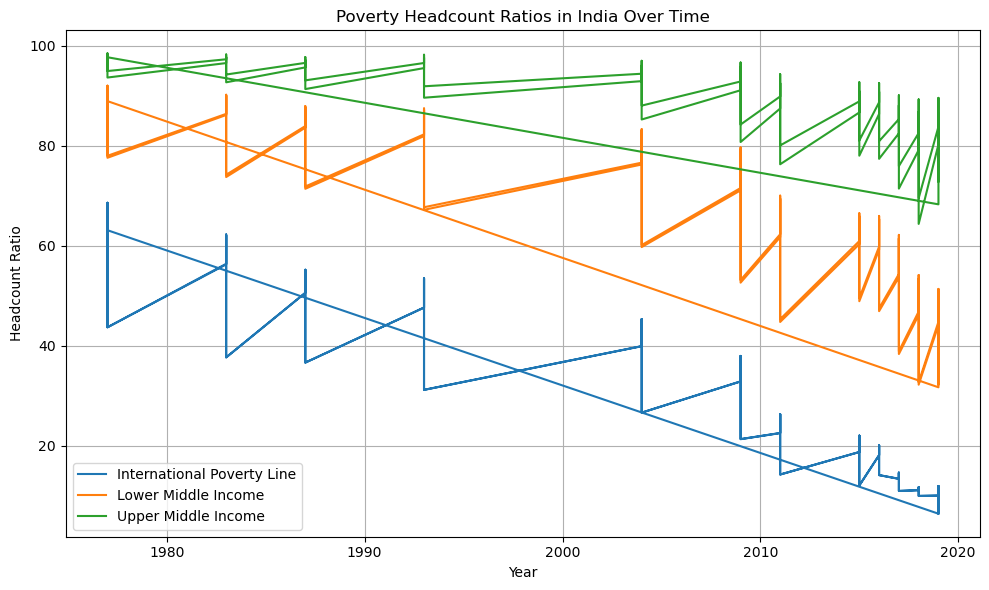

In [24]:
# Load your dataset
df = pd.read_csv('pip_dataset.csv')  

# Convert 'year' column to integer 
df['year'] = df['year'].astype(int)

# Drop missing and duplicate values
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Filter for a single country India
country_df = df[df['country'] == 'India']

# Plot headcount ratios for India over time
plt.figure(figsize=(10, 6))
plt.plot(country_df['year'], country_df['headcount_ratio_international_povline'], label='International Poverty Line')
plt.plot(country_df['year'], country_df['headcount_ratio_lower_mid_income_povline'], label='Lower Middle Income')
plt.plot(country_df['year'], country_df['headcount_ratio_upper_mid_income_povline'], label='Upper Middle Income')
plt.title('Poverty Headcount Ratios in India Over Time')
plt.xlabel('Year')
plt.ylabel('Headcount Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
def basic_eda(df):
    print("Basic Statistics:\n", df.describe())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nData Types:\n", df.dtypes)

basic_eda(df)

Basic Statistics:
               year  ppp_version  survey_year  survey_comparability  \
count  3643.000000  3643.000000  3643.000000           3643.000000   
mean   2005.715893  2013.969531  2005.774096              1.701071   
std       9.498677     3.000257     9.489738              1.434786   
min    1967.000000  2011.000000  1967.000000              0.000000   
25%    2000.000000  2011.000000  2000.000000              1.000000   
50%    2007.000000  2011.000000  2007.000000              1.000000   
75%    2013.000000  2017.000000  2013.115000              3.000000   
max    2021.000000  2017.000000  2021.000000              6.000000   

       headcount_ratio_international_povline  \
count                            3643.000000   
mean                               12.138591   
std                                18.918983   
min                                 0.003111   
25%                                 0.499448   
50%                                 3.040325   
75%           

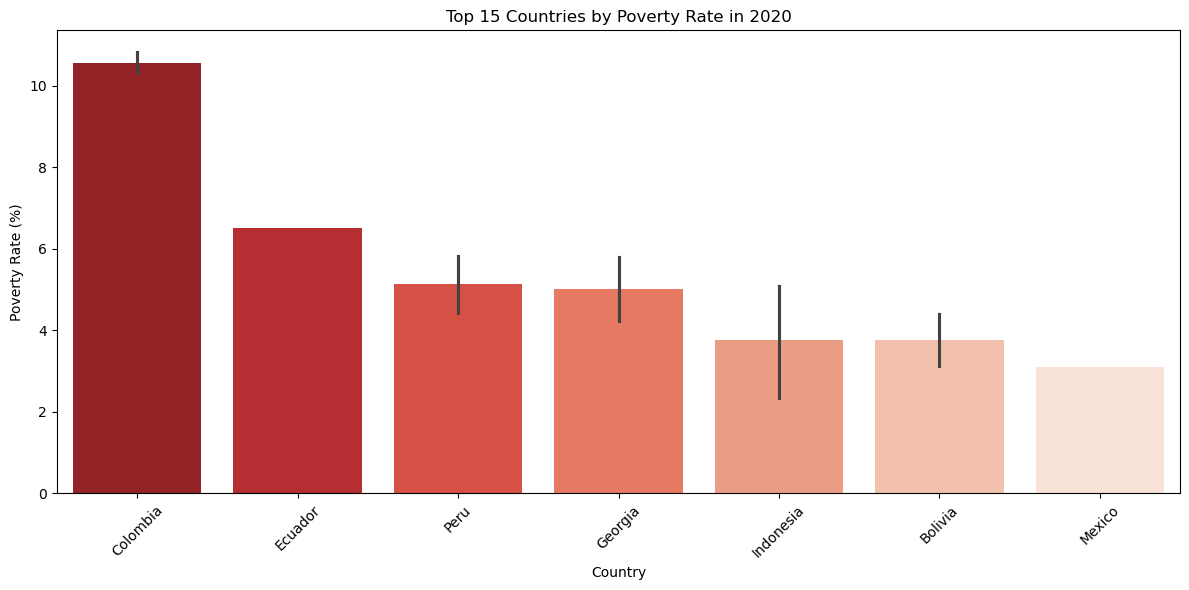

In [16]:
def plot_poverty_by_country(df, year):
    df_year = df[df['year'] == year]
    poverty = df_year.sort_values(by='headcount_ratio_international_povline', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=poverty.head(15),
        x='country',
        y='headcount_ratio_international_povline',
        hue='country',  
        palette='Reds_r',
        dodge=False
    )
    plt.title(f'Top 15 Countries by Poverty Rate in {year}')
    plt.xlabel('Country')
    plt.ylabel('Poverty Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_poverty_by_country(df, 2020)

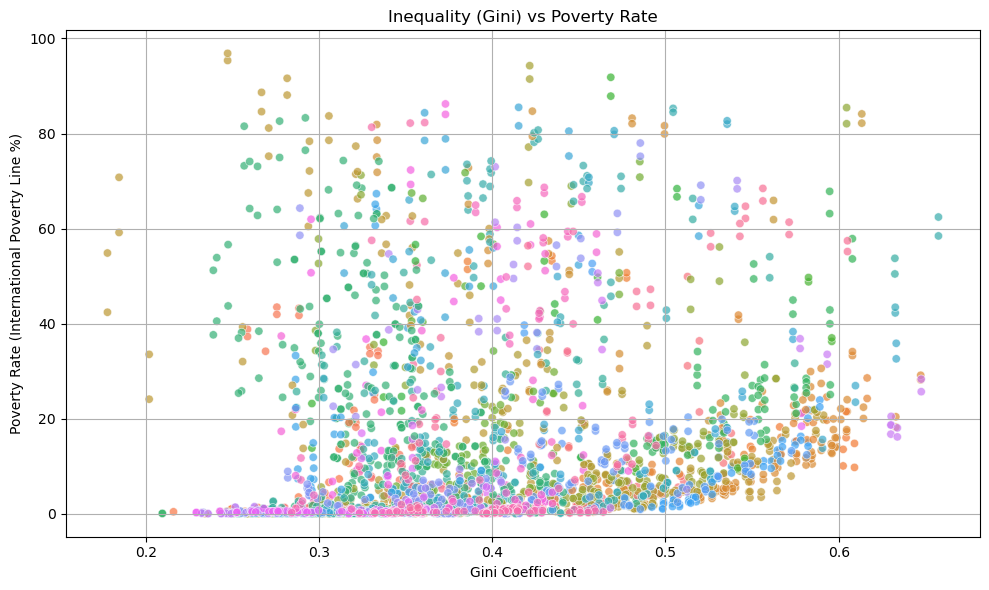

In [18]:
def inequality_vs_poverty(df):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x='gini',
        y='headcount_ratio_international_povline',
        hue='country',
        alpha=0.7,
        legend=False  
    )
    plt.title('Inequality (Gini) vs Poverty Rate')
    plt.xlabel('Gini Coefficient')
    plt.ylabel('Poverty Rate (International Poverty Line %)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

inequality_vs_poverty(df)

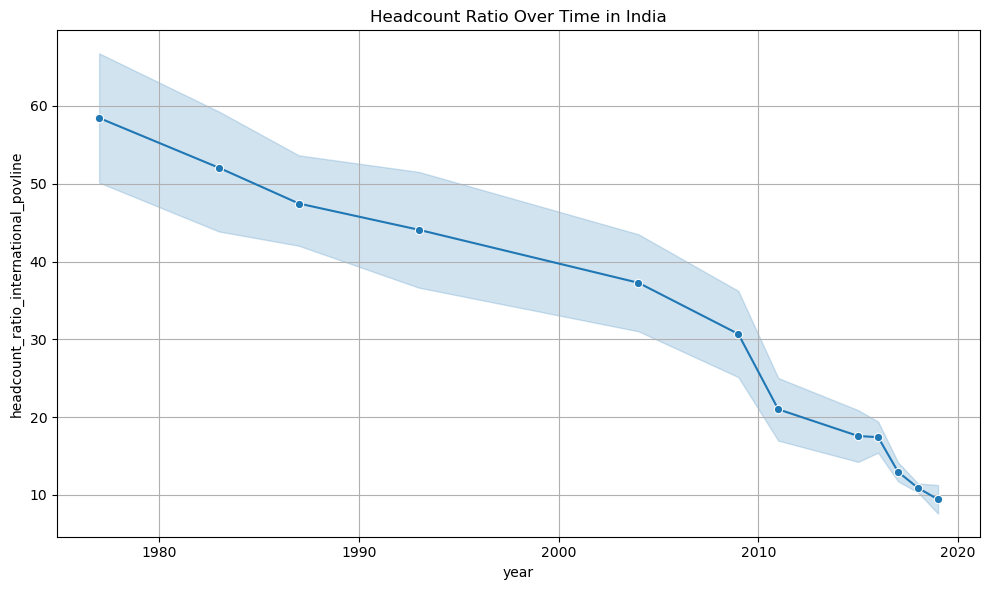

In [20]:
def health_trends(df, country):
    country_df = df[df['country'] == country].sort_values('year')

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=country_df, x='year', y='headcount_ratio_international_povline', marker='o')
    plt.title(f'Headcount Ratio Over Time in {country}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

health_trends(df, 'India')

In [22]:
def top_bottom_poverty(df, year):
    # Filter the dataset for the given year
    df_year = df[df['year'] == year]

    # Check for empty data
    if df_year.empty:
        print(f"No data found for the year {year}")
        return

    # Get top 5 countries with the lowest and highest poverty rates
    top = df_year.nsmallest(5, 'headcount_ratio_international_povline')
    bottom = df_year.nlargest(5, 'headcount_ratio_international_povline')

    print(f"\nTop 5 Countries with Lowest Poverty Rates in {year}:\n", top[['country', 'headcount_ratio_international_povline']])
    print(f"\nTop 5 Countries with Highest Poverty Rates in {year}:\n", bottom[['country', 'headcount_ratio_international_povline']])

top_bottom_poverty(df, 2020)



Top 5 Countries with Lowest Poverty Rates in 2020:
       country  headcount_ratio_international_povline
2363  Uruguay                               0.184260
4801  Uruguay                               0.203018
73    Armenia                               0.388135
330     Chile                               0.674660
2768    Chile                               0.749503

Top 5 Countries with Highest Poverty Rates in 2020:
        country  headcount_ratio_international_povline
2854  Colombia                              10.821042
416   Colombia                              10.315916
627    Ecuador                               6.519245
3065   Ecuador                               6.519245
4194      Peru                               5.825761
